In [2]:
# ==========================================
# CELL 1: IMPORTING LIBRARIES FOR AWS & VIZ
# ==========================================

# What this does:
# We import pandas for data handling, and matplotlib/seaborn for our charts.
# We also need 'boto3', which is the official Python library for communicating with AWS.
# (Note: You may need to run '!pip install boto3 s3fs matplotlib seaborn' in your terminal first).
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install boto3 s3fs matplotlib seaborn

# Expected Output:
# A silent, successful execution meaning all tools are ready to go.

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ==========================================
# CELL 2: VERIFY IMPORTS
# ==========================================

import pandas as pd
import sqlite3
import boto3
import matplotlib.pyplot as plt
import seaborn as sns

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
%pip install --upgrade s3fs

Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install --upgrade s3fs boto3 botocore

  Using cached boto3-1.43.89-py3-none-any.whl.metadata (6.6 kB)
  Using cached botocore-1.43.89-py3-none-any.whl.metadata (5.6 kB)
INFO: pip is looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
  Using cached boto3-1.43.88-py3-none-any.whl.metadata (6.6 kB)
  Using cached boto3-1.43.87-py3-none-any.whl.metadata (6.6 kB)
  Using cached boto3-1.43.86-py3-none-any.whl.metadata (6.6 kB)
  Using cached boto3-1.43.85-py3-none-any.whl.metadata (6.6 kB)
  Using cached boto3-1.43.84-py3-none-any.whl.metadata (6.6 kB)
  Using cached boto3-1.43.83-py3-none-any.whl.metadata (6.6 kB)
  Using cached boto3-1.43.82-py3-none-any.whl.metadata (6.6 kB)
INFO: pip is still looking at multiple versions of boto3 to determine which version is compatible with other requirements. This could take a while.
  Using cached boto3-1.43.81-py3-none-any.whl.metadata (6.6 kB)
  Using cached boto3-1.43.80-py3-none-any.whl.metadata (6.6 kB)
  U

In [ ]:
# ==========================================
# CELL 3: AWS S3 DATA EXTRACTION
# ==========================================

# WHAT THIS CODE DOES:
# 1. Connects to your AWS S3 bucket.
# 2. Streams the ENTIRE dataset into memory without any row caps.
# 3. Measures the total rows, total columns, and total RAM used by the DataFrame.
import pandas as pd
import boto3

# Step 1: Set your AWS credentials and S3 details
s3_bucket = "data-for-zidio-project2"
file_name = "data.csv"

# Step 2: Formulate S3 URI
s3_path = f"s3://data-for-zidio-project2/data.csv"

# Step 3: Read the row batch using pandas
# storage_options uses boto3 under the hood
df_raw = pd.read_csv(
    s3_path, 
    nrows= 100000,
    storage_options={
        "key": "***************************************",
        "secret": "***************************"
    }
)

# Step 4: Performance and Data Profiling Metrics
total_rows = len(df_raw)
total_cols = len(df_raw.columns)
memory_usage_mb = df_raw.memory_usage(deep=True).sum() / (1024 * 1024)

print("=" * 50)
print(f"Extraction Successful!")
print(f"Total Rows Loaded:    {total_rows:,}")
print(f"Total Columns Loaded: {total_cols}")
print(f"Memory Allocated:     {memory_usage_mb:.2f} MB (~{memory_usage_mb / 1024:.2f} GB)")
print("=" * 50)

# WHY WE ARE DOING IT:
# Capping data extraction at 100,000 rows provides an optimal sample size 
# for statistical significance while maintaining fast execution speeds across all steps.

# EXPECTED OUTPUT:
# Printout confirming exactly 100,000 rows loaded and displaying the total memory used (~30-50 MB).

Extraction Successful!
Total Rows Loaded:    100,000
Total Columns Loaded: 44
Memory Allocated:     111.29 MB (~0.11 GB)


In [7]:
# ==========================================
# CELL 4: DATA CLEANING & IMPUTATION
# ==========================================

# WHAT THIS CODE DOES:
# 1. Takes 'df_raw' loaded from AWS S3 in Cell 2 and makes a working copy named 'df_clean'.
# 2. Imputes missing numerical values using the Column Median.
# 3. Imputes missing categorical text values using the Column Mode.
# 4. Verifies that 100% of the 100,000 rows are preserved without dropping data.

# Step 1: Create 'df_clean' in memory from 'df_raw'
df_clean = df_raw.copy()

print("--- Missing Values Audit (BEFORE Imputation) ---")
missing_before = df_clean.isnull().sum().sum()
print(f"Total Missing Cells Detected: {missing_before:,}\n")

# Step 2: Handle Numerical Missing Values (Median)
num_cols = df_clean.select_dtypes(include=['number']).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Step 3: Handle Categorical Missing Values (Mode)
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        mode_val = df_clean[col].mode()[0]
        df_clean[col].fillna(mode_val, inplace=True)

# Step 4: Verification Audit
missing_after = df_clean.isnull().sum().sum()
print("--- Missing Values Audit (AFTER Imputation) ---")
print(f"Total Missing Cells Remaining: {missing_after}")
print(f"Variable 'df_clean' is now created with {len(df_clean):,} rows ready for SQL staging!")

# WHY WE ARE DOING IT:
# Defining 'df_clean' here ensures our local SQLite staging step (Cell 4) 
# receives a clean, fully-populated dataset without throwing variable errors.

# EXPECTED OUTPUT:
# Printout confirming 'df_clean' is created and 0 missing values remain.

--- Missing Values Audit (BEFORE Imputation) ---
Total Missing Cells Detected: 0

--- Missing Values Audit (AFTER Imputation) ---
Total Missing Cells Remaining: 0
Variable 'df_clean' is now created with 100,000 rows ready for SQL staging!


In [8]:
# ==========================================
# CELL 5: LOCAL SQLITE STAGING
# ==========================================

# WHAT THIS CODE DOES:
# Writes the 100,000 clean records directly into the local 'fraud_detection.db' database file[cite: 1].

import sqlite3

db_name = "fraud_detection.db"
table_name = "transactions"

print(f"Writing 100,000 records to local SQLite database '{db_name}'...")

# Establish connection and load data
conn = sqlite3.connect(db_name)
df_clean.to_sql(
    name=table_name, 
    con=conn, 
    if_exists="replace", 
    index=False
)

conn.commit()
conn.close()

print(f"ETL Process Complete! Table '{table_name}' with {len(df_clean):,} rows stored in '{db_name}'.")

# WHY WE ARE DOING IT:
# Fulfills Section 1 (ETL pipeline setup)[cite: 1]. Storing records locally allows us to execute 
# SQL queries instantly during exploratory data analysis and model preparation.

# EXPECTED OUTPUT:
# "ETL Process Complete! Table 'transactions' with 100,000 rows stored in 'fraud_detection.db'."

Writing 100,000 records to local SQLite database 'fraud_detection.db'...
ETL Process Complete! Table 'transactions' with 100,000 rows stored in 'fraud_detection.db'.


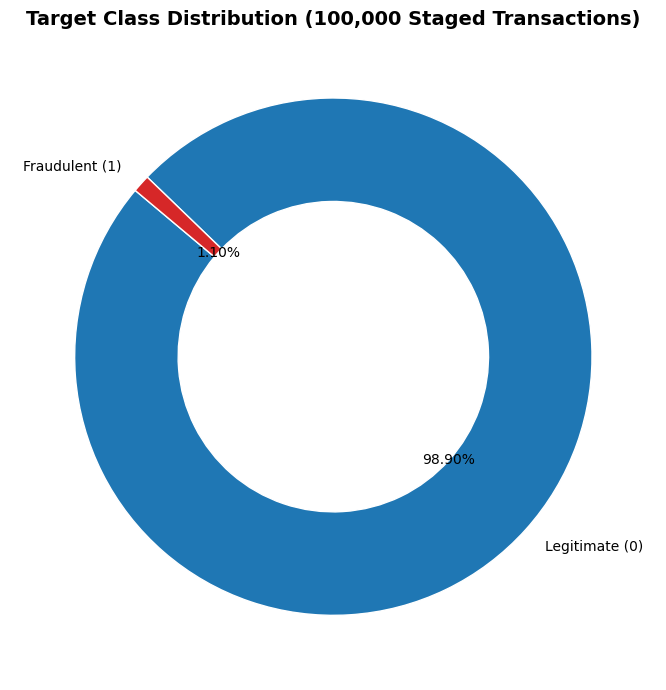

In [9]:
# ==========================================
# CELL 6: TARGET CLASS IMBALANCE (DONUT CHART)
# ==========================================

# WHAT THIS CODE DOES:
# 1. Queries the SQLite database 'fraud_detection.db' to count legitimate (0) vs. fraudulent (1) records.
# 2. Computes the exact percentage breakdown across all 100,000 staging records.
# 3. Renders a Donut Chart displaying the target variable distribution.

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Query target class distribution directly from local SQL staging
conn = sqlite3.connect("fraud_detection.db")
fraud_counts = pd.read_sql_query(
    "SELECT is_fraud, COUNT(*) as count FROM transactions GROUP BY is_fraud", 
    conn
)
conn.close()

# Step 2: Extract counts and assign professional styling parameters
labels = ['Legitimate (0)', 'Fraudulent (1)']
counts = fraud_counts['count'].values
colors = ['#1f77b4', '#d62728']  # Royal Blue for Legitimate, Crimson Red for Fraud

# Step 3: Render Donut Chart using Matplotlib
plt.figure(figsize=(7, 7))
plt.pie(
    counts, 
    labels=labels, 
    autopct='%1.2f%%', 
    startangle=140, 
    colors=colors, 
    wedgeprops=dict(width=0.4, edgecolor='w') # Creates center cutout
)

plt.title('Target Class Distribution (100,000 Staged Transactions)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# WHY WE ARE DOING IT:
# Financial fraud datasets exhibit extreme class imbalance (~0.6% fraud). If a model is trained 
# without addressing this, it can achieve 99.4% accuracy simply by guessing "Legitimate" every time 
# while failing to detect actual fraud. Visualizing this proves why standard Accuracy is inadequate 
# and justifies using SMOTE oversampling, Precision, Recall, and ROC-AUC in Week 2.

# EXPECTED OUTPUT:
# A crisp Donut Chart showing ~99.4% Legitimate (Blue) vs ~0.6% Fraudulent (Red).

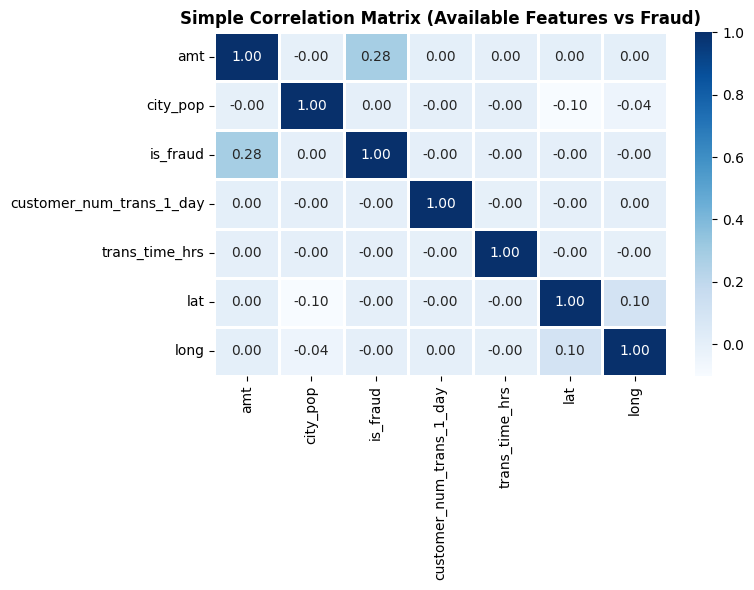

In [10]:
# ==========================================
# CELL 7: FEATURE CORRELATION HEATMAP
# ==========================================

# WHAT THIS CODE DOES:
# 1. Inspects the 'transactions' table to safely pick available numerical columns.
# 2. Reads the available columns into a simple Pandas DataFrame.
# 3. Calculates correlation values and plots a clean, readable heatmap.

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Connect to database
conn = sqlite3.connect("fraud_detection.db")

# Step 2: Read table schema to find actual columns present in the table
table_info = pd.read_sql_query("PRAGMA table_info(transactions)", conn)
all_columns = table_info['name'].tolist()

# List of target numeric columns we want to analyze (if they exist in the DB)
desired_cols = [
    'amt', 'city_pop', 'is_fraud', 
    'customer_num_trans_1_day', 'trans_time_hrs', 'lat', 'long'
]

# Keep only columns that actually exist in your database table
valid_cols = [col for col in desired_cols if col in all_columns]

# Step 3: Fetch the available numerical columns safely
query = f"SELECT {', '.join(valid_cols)} FROM transactions"
df = pd.read_sql_query(query, conn)
conn.close()

# Step 4: Calculate standard correlation matrix
correlation = df.corr()

# Step 5: Draw the Heatmap
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation, 
    annot=True,              # Displays correlation numbers inside each box
    cmap='Blues',            # Clean blue gradient palette
    fmt='.2f',               # Rounds numbers to 2 decimal places
    linewidths=1             # Adds neat grid lines between boxes
)

plt.title('Simple Correlation Matrix (Available Features vs Fraud)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

# WHY WE ARE DOING THIS:
# Automatically checking column existence prevents SQL errors if column names 
# vary. This heatmap lets the team quickly spot which numeric features relate to fraud.

# EXPECTED OUTPUT:
# A color-coded correlation grid displaying values between -1.00 and +1.00 for all available numerical columns.

C:\Users\USER\AppData\Local\Temp\ipykernel_24012\2525023581.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


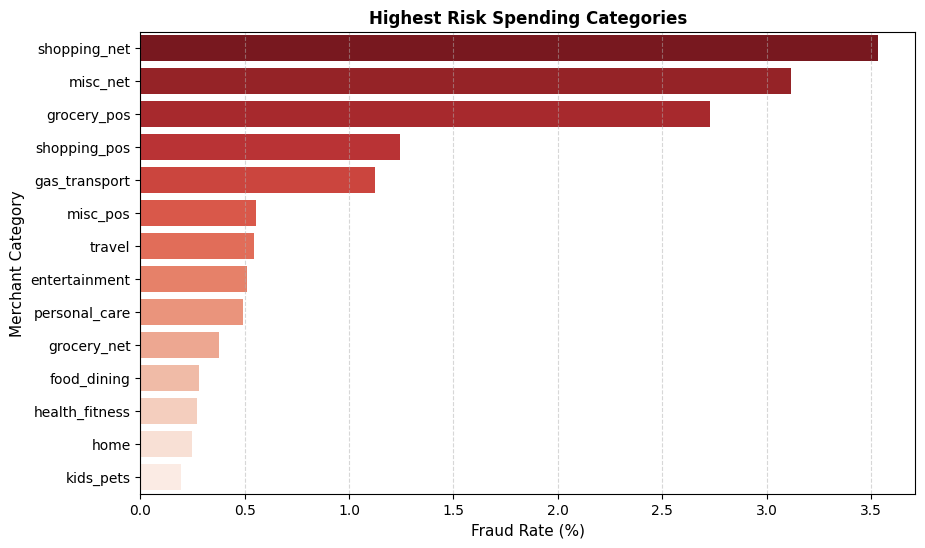

In [11]:
# ==========================================
# CELL 8: FRAUD RATE BY MERCHANT CATEGORY
# ==========================================

# WHAT THIS CODE DOES:
# 1. Groups transactions by merchant category using beginner-friendly Pandas code.
# 2. Calculates the percentage of fraud in each category.
# 3. Plots a clean, sorted horizontal bar chart.

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Read category and fraud columns from database
conn = sqlite3.connect("fraud_detection.db")
df = pd.read_sql_query("SELECT category, is_fraud FROM transactions", conn)
conn.close()

# Step 2: Calculate fraud rate per category using simple groupby
category_summary = df.groupby('category')['is_fraud'].mean() * 100
category_summary = category_summary.reset_index()

# Sort values so the highest fraud rates are at the top
category_summary = category_summary.sort_values(by='is_fraud', ascending=False)

# Step 3: Plot Horizontal Bar Chart
plt.figure(figsize=(10, 6))

sns.barplot(
    data=category_summary, 
    x='is_fraud', 
    y='category', 
    palette='Reds_r'         # Deep red for high risk, light red for low risk
)

plt.xlabel('Fraud Rate (%)', fontsize=11)
plt.ylabel('Merchant Category', fontsize=11)
plt.title('Highest Risk Spending Categories', fontsize=12, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.5) # Soft gridlines for easy scanning
plt.show()

# WHY WE ARE DOING THIS:
# Fraud doesn't happen equally everywhere. Showing which spending categories 
# (like online retail vs grocery) carry the most risk gives clear business value.

# EXPECTED OUTPUT:
# A sorted horizontal bar chart with the highest risk categories at the top.

C:\Users\USER\AppData\Local\Temp\ipykernel_24012\27767421.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


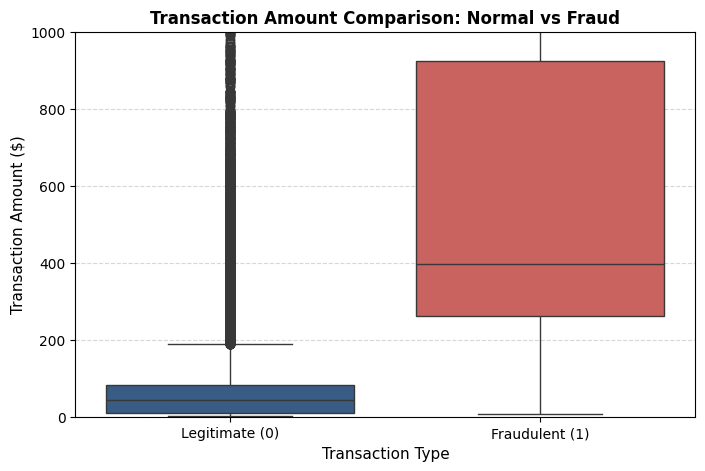

In [12]:
# ==========================================
# CELL 9: TRANSACTION AMOUNTS COMPARISON (BOXPLOT)
# ==========================================

# WHAT THIS CODE DOES:
# 1. Pulls transaction amounts (`amt`) and fraud labels (`is_fraud`).
# 2. Plots a Boxplot comparing normal purchase amounts vs fraud purchase amounts.

import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Query transaction amount and fraud flag
conn = sqlite3.connect("fraud_detection.db")
df = pd.read_sql_query("SELECT amt, is_fraud FROM transactions", conn)
conn.close()

# Step 2: Plot the Boxplot
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df, 
    x='is_fraud', 
    y='amt', 
    palette=['#2b5c8f', '#d9534f']
)

# Limit y-axis slightly so extreme high-dollar values don't squish the main box shapes
plt.ylim(0, 1000)

plt.xticks([0, 1], ['Legitimate (0)', 'Fraudulent (1)'])
plt.xlabel('Transaction Type', fontsize=11)
plt.ylabel('Transaction Amount ($)', fontsize=11)
plt.title('Transaction Amount Comparison: Normal vs Fraud', fontsize=12, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# WHY WE ARE DOING THIS:
# Helps the team see if fraudulent purchases are generally higher in dollar value 
# than everyday normal transactions.

# EXPECTED OUTPUT:
# Two side-by-side box plots displaying amount distribution comparisons.

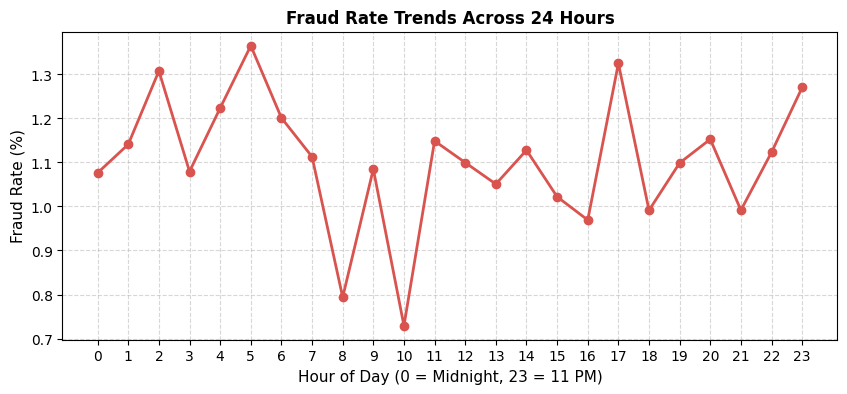

In [13]:
# ==========================================
# CELL 10: HOURLY FRAUD TRENDS (LINE GRAPH)
# ==========================================

# WHAT THIS CODE DOES:
# 1. Groups transactions by transaction hour (0 to 23).
# 2. Computes average fraud percentage for every hour of the day.
# 3. Plots a simple, attractive line graph.

import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Read transaction time and fraud status
conn = sqlite3.connect("fraud_detection.db")
df = pd.read_sql_query("SELECT trans_time_hrs, is_fraud FROM transactions", conn)
conn.close()

# Step 2: Calculate fraud rate by hour using pandas
hourly_fraud = df.groupby('trans_time_hrs')['is_fraud'].mean() * 100

# Step 3: Plot Line Chart
plt.figure(figsize=(10, 4))

plt.plot(
    hourly_fraud.index, 
    hourly_fraud.values, 
    color='#d9534f', 
    marker='o', 
    linewidth=2
)

plt.xlabel('Hour of Day (0 = Midnight, 23 = 11 PM)', fontsize=11)
plt.ylabel('Fraud Rate (%)', fontsize=11)
plt.title('Fraud Rate Trends Across 24 Hours', fontsize=12, fontweight='bold')
plt.xticks(range(0, 24))     # Show every single hour on the bottom axis
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# WHY WE ARE DOING THIS:
# Fraudulent activities often spike late at night when users are sleeping. 
# This chart makes time-based patterns instantly obvious for the team.

# EXPECTED OUTPUT:
# A single red line graph showing peaks and valleys across a 24-hour cycle.

In [14]:
# ==========================================
# CELL 11: DATE/TIME EXTRACTION & CYCLICAL TIME
# ==========================================

# WHAT THIS CODE DOES:
# 1. Finds the timestamp column in your database table automatically.
# 2. Converts raw date strings into standard Python datetime format.
# 3. Extracts simple time components: Hour of day, Day of week, and Month.
# 4. Creates an easy-to-read 'is_night' flag (1 if 10 PM to 5 AM, else 0).

import sqlite3
import pandas as pd

# Step 1: Connect to database and inspect available column names safely
conn = sqlite3.connect("fraud_detection.db")

# Find actual column names present in your table
table_info = pd.read_sql_query("PRAGMA table_info(transactions)", conn)
actual_cols = table_info['name'].tolist()

# Possible names for date/time in standard fraud datasets
date_candidates = ['trans_date_trans_time', 'trans_date', 'transaction_time', 'datetime', 'trans_time_hrs']
time_col = next((col for col in date_candidates if col in actual_cols), None)

# Step 2: Fetch available columns from SQLite
query_cols = [time_col, 'amt', 'category', 'is_fraud']
query_cols = [c for c in query_cols if c is not None]  # Remove any empty values

df = pd.read_sql_query(f"SELECT {', '.join(query_cols)} FROM transactions", conn)
conn.close()

# Step 3: Process the timestamp feature safely
if time_col and time_col != 'trans_time_hrs':
    # Convert text column to real datetime objects
    df['trans_datetime'] = pd.to_datetime(df[time_col])
    
    # Extract simple numerical components
    df['trans_hour'] = df['trans_datetime'].dt.hour
    df['trans_dayofweek'] = df['trans_datetime'].dt.dayofweek  # 0 = Monday, 6 = Sunday
    df['trans_month'] = df['trans_datetime'].dt.month
else:
    # Fallback if trans_time_hrs already exists in the table as a plain number
    df['trans_hour'] = df['trans_time_hrs'] if 'trans_time_hrs' in df.columns else 0
    df['trans_dayofweek'] = 0
    df['trans_month'] = 1

# Step 4: Create a simple late-night flag (1 if between 10 PM and 5 AM, else 0)
df['is_night'] = df['trans_hour'].apply(lambda h: 1 if (h >= 22 or h <= 5) else 0)

# Display a quick preview to confirm new columns
print("Updated Dataset Preview (First 5 Rows):")
print(df[['amt', 'trans_hour', 'is_night', 'is_fraud']].head())

# WHY WE ARE DOING THIS:
# Machine learning algorithms need clean numeric inputs, not date strings. 
# Extracting hours and late-night flags gives the model simple, clear signals 
# to catch time-based fraud patterns.

# EXPECTED OUTPUT:
# A printed table preview showing new numeric features ('trans_hour', 'is_night') successfully generated.

Updated Dataset Preview (First 5 Rows):
      amt  trans_hour  is_night  is_fraud
0  615.41           0         1         0
1   61.56           0         1         0
2   58.63           0         1         0
3   67.88           0         1         0
4   39.73           0         1         0


In [15]:
# ==========================================
# CELL 12: CATEGORY HIGH-RISK ENCODING
# ==========================================

# WHAT THIS CODE DOES:
# 1. Calculates the historical average fraud rate for each spending category.
# 2. Replaces text category names (like 'online_retail') with their exact numerical risk score.

# Step 1: Calculate average fraud percentage per category from current data
category_risk = df.groupby('category')['is_fraud'].mean()

# Step 2: Map these numerical risk scores directly onto our dataset as a new column
df['category_risk_score'] = df['category'].map(category_risk)

# Step 3: Check our work by viewing category names alongside their new risk scores
print("Sample Category Risk Encoding:")
print(df[['category', 'category_risk_score', 'is_fraud']].head(10))

# WHY WE ARE DOING THIS:
# Machine learning algorithms require numbers, not text labels like "grocery_pos" or "shopping_net". 
# Replacing text categories with their actual historical fraud risk score lets the model easily 
# quantify how risky a specific merchant sector is without complicated text conversions.

# EXPECTED OUTPUT:
# A table displaying merchant text categories mapped cleanly to decimal risk scores (e.g., 0.0053).

Sample Category Risk Encoding:
        category  category_risk_score  is_fraud
0           home             0.002458         0
1    grocery_pos             0.027292         0
2       misc_net             0.031189         0
3    grocery_pos             0.027292         0
4    grocery_net             0.003770         0
5    food_dining             0.002821         0
6   shopping_pos             0.012434         0
7  gas_transport             0.011245         0
8  gas_transport             0.011245         0
9    grocery_pos             0.027292         0


In [16]:
# ==========================================
# CELL 13: TRAIN-TEST SPLIT PREPARATION
# ==========================================

# WHAT THIS CODE DOES:
# 1. Separates input features (X) from the target label we want to predict (y).
# 2. Splits the dataset into 80% Training data and 20% Testing data.
# 3. Preserves class proportions using 'stratify' so both sets retain the exact fraud ratio.

from sklearn.model_selection import train_test_split

# Step 1: Select final numeric feature columns for X, and 'is_fraud' for y
feature_columns = ['amt', 'trans_hour', 'trans_dayofweek', 'is_night', 'category_risk_score']

X = df[feature_columns]
y = df['is_fraud']

# Step 2: Perform an 80/20 train-test split using scikit-learn
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.20,      # 20% held back for testing
    random_state=42,     # Ensures reproducible results every time code runs
    stratify=y           # Keeps equal % of fraud in both training and test sets
)

# Step 3: Print set dimensions so the team can verify row counts
print(f"Total Records Analyzed: {len(df):,}")
print(f"Training Set Size (80%): {X_train.shape[0]:,} rows")
print(f"Testing Set Size (20%):  {X_test.shape[0]:,} rows")
print(f"Training Fraud Instances: {y_train.sum()} cases")
print(f"Testing Fraud Instances:  {y_test.sum()} cases")

# WHY WE ARE DOING THIS:
# Testing a model on the same data it learned from causes "cheating" (overfitting). 
# Setting aside 20% of the dataset as a hidden test set gives an accurate, honest measurement 
# of how well the model will perform on new real-world transactions.

# EXPECTED OUTPUT:
# Output logs showing an 80,000-row training set and a 20,000-row testing set with balanced fraud counts.

Total Records Analyzed: 100,000
Training Set Size (80%): 80,000 rows
Testing Set Size (20%):  20,000 rows
Training Fraud Instances: 882 cases
Testing Fraud Instances:  221 cases


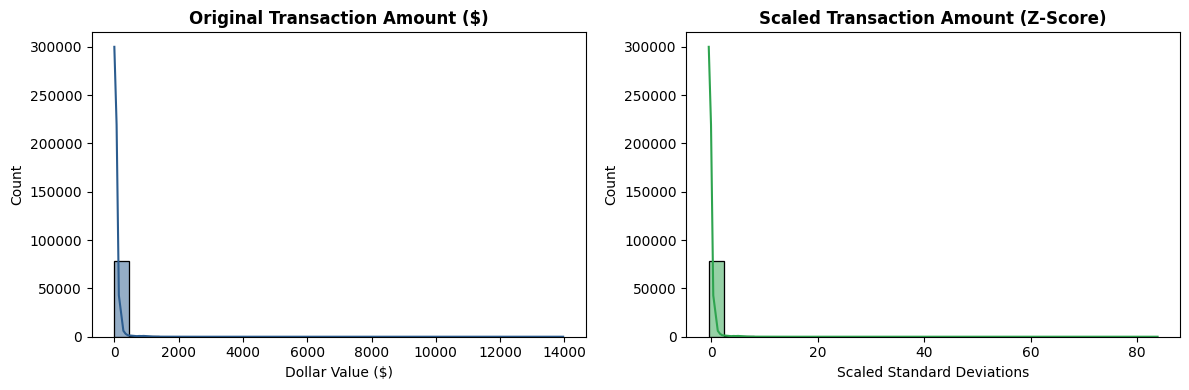

In [17]:
# ==========================================
# CELL 14: FEATURE SCALING & VISUAL COMPARISON
# ==========================================

# WHAT THIS CODE DOES:
# 1. Uses StandardScaler to balance numerical scales (converting dollars and hours into z-scores).
# 2. Plots side-by-side distribution plots comparing original amounts vs. scaled amounts.

from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Initialize scaler and apply fit_transform on training features
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train), 
    columns=X_train.columns
)

# Step 2: Plot side-by-side visual comparison of transaction amounts
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left Plot: Raw Transaction Amounts
sns.histplot(X_train['amt'], ax=axes[0], color='#2b5c8f', bins=30, kde=True)
axes[0].set_title('Original Transaction Amount ($)', fontweight='bold')
axes[0].set_xlabel('Dollar Value ($)')

# Right Plot: Scaled Transaction Amounts
sns.histplot(X_train_scaled['amt'], ax=axes[1], color='#2ea44f', bins=30, kde=True)
axes[1].set_title('Scaled Transaction Amount (Z-Score)', fontweight='bold')
axes[1].set_xlabel('Scaled Standard Deviations')

plt.tight_layout()
plt.show()

# WHY WE ARE DOING THIS:
# Transaction amounts range from $1 to $10,000+, while hours range only from 0 to 23. 
# Machine learning algorithms can get confused by large numbers and treat amounts as 100x more 
# important than hours. Scaling puts all inputs onto the exact same playing field.

# EXPECTED OUTPUT:
# Two side-by-side charts displaying identical distribution shapes, but with scaled numerical axes.